In [39]:
import bisect
import time
import matplotlib.pyplot as plt
import numpy as np

def compute_last_compatible(intervals):
    """Находит индекс последнего непересекающегося интервала для каждого интервала."""
    end_times = [interval[1] for interval in intervals]
    p = [-1] * len(intervals)
    
    for i in range(len(intervals)):
        idx = bisect.bisect_right(end_times, intervals[i][0]) - 1
        p[i] = idx
    return p

def weighted_interval_scheduling(intervals):
    """Возвращает максимальный вес и список выбранных интервалов."""
    intervals = sorted(intervals, key=lambda x: x[1])
    
    p = compute_last_compatible(intervals)
    n = len(intervals)
    
    dp = [0] * n
    for i in range(n):
        include = intervals[i][2] + (dp[p[i]] if p[i] != -1 else 0)
        exclude = dp[i-1] if i > 0 else 0
        dp[i] = max(include, exclude)
    
    selected = []
    i = n - 1
    while i >= 0:
        include = intervals[i][2] + (dp[p[i]] if p[i] != -1 else 0)
        exclude = dp[i-1] if i > 0 else 0
        if include >= exclude:  
            selected.append(intervals[i])
            i = p[i]
        else:
            i -= 1
    selected.reverse()
    
    return dp[-1], selected

In [40]:
import random

def generate_random_intervals(n, start_range=0, end_range=20, min_len=1, max_len=5, min_weight=1, max_weight=10):
    """Генерирует список n случайных интервалов (start, end, weight)."""
    intervals = []
    for _ in range(n):
        start = random.randint(start_range, end_range - min_len)
        length = random.randint(min_len, max_len)
        end = start + length
        weight = random.randint(min_weight, max_weight)
        intervals.append((start, end, weight))
    return intervals

intervals = generate_random_intervals(10)
print("Случайные интервалы:", intervals)

max_weight, chosen_intervals = weighted_interval_scheduling(intervals)
print("Максимальный вес:", max_weight)
print("Выбранные интервалы:", chosen_intervals)

Случайные интервалы: [(19, 21, 3), (16, 18, 7), (15, 18, 1), (10, 11, 9), (16, 17, 8), (18, 22, 8), (5, 7, 10), (0, 5, 4), (19, 23, 9), (5, 6, 4)]
Максимальный вес: 40
Выбранные интервалы: [(0, 5, 4), (5, 7, 10), (10, 11, 9), (16, 17, 8), (19, 23, 9)]


In [41]:
def measure_algorithm_time(algorithm, input_generator, n, n_trials=20, to_ms=False):
    """
    Измеряет время работы алгоритма для заданного размера входа.
    
    Параметры:
    - algorithm: функция алгоритма (например, weighted_interval_scheduling)
    - input_generator: функция генерации входных данных, принимает n
    - n: размер входа (например, количество интервалов)
    - n_trials: количество повторов
    - to_ms: True, если время нужно в миллисекундах
    """
    trial_times = []
    for _ in range(n_trials):
        data = input_generator(n)
        start = time.perf_counter()
        algorithm(data)
        end = time.perf_counter()
        elapsed = (end - start) * 1000 if to_ms else (end - start)
        trial_times.append(elapsed)
    trial_times = np.array(trial_times)
    mean_t = trial_times.mean()
    std_t = trial_times.std()
    return trial_times, mean_t, std_t

In [42]:
sizes = [10, 20, 50, 100, 200, 400, 800]
n_trials_graph = 20
n_trials_hist = 1000
n_hist = 20  

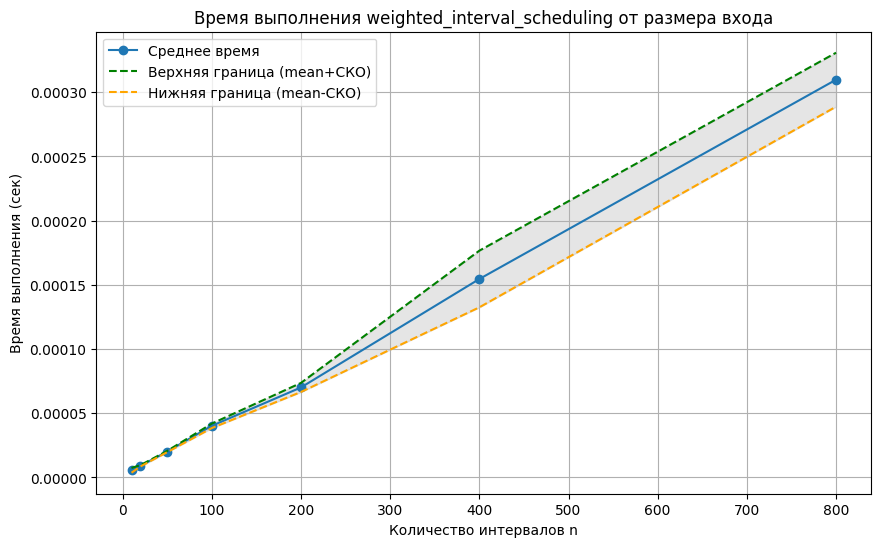

In [43]:
mean_times = []
std_times = []

for n in sizes:
    _, mean_t, std_t = measure_algorithm_time(weighted_interval_scheduling, generate_random_intervals, n, n_trials=n_trials_graph)
    mean_times.append(mean_t)
    std_times.append(std_t)

mean_times = np.array(mean_times)
std_times = np.array(std_times)

upper = mean_times + std_times
lower = mean_times - std_times

plt.figure(figsize=(10,6))
plt.plot(sizes, mean_times, 'o-', label='Среднее время')
plt.plot(sizes, upper, '--', color='green', label='Верхняя граница (mean+СКО)')
plt.plot(sizes, lower, '--', color='orange', label='Нижняя граница (mean-СКО)')
plt.fill_between(sizes, lower, upper, color='gray', alpha=0.2)
plt.xlabel('Количество интервалов n')
plt.ylabel('Время выполнения (сек)')
plt.title('Время выполнения weighted_interval_scheduling от размера входа')
plt.grid(True)
plt.legend()
plt.show()

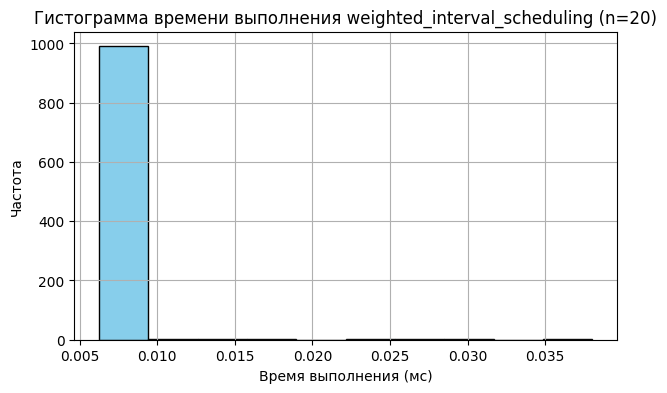

Среднее время: 0.006922 мс, Стандартное отклонение: 0.001606 мс


In [44]:
times, mean_t, std_t = measure_algorithm_time(weighted_interval_scheduling, generate_random_intervals, n_hist, n_trials=n_trials_hist, to_ms=True)

plt.figure(figsize=(7,4))
plt.hist(times, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Время выполнения (мс)')
plt.ylabel('Частота')
plt.title(f'Гистограмма времени выполнения weighted_interval_scheduling (n={n_hist})')
plt.grid(True)
plt.show()

print(f"Среднее время: {mean_t:.6f} мс, Стандартное отклонение: {std_t:.6f} мс")